# Capstone Project: Sales EDA, Regression Modeling & Insights

**Dataset:** Financial/Sales sample (700 rows, 16 columns) — Segment, Country, Product, Discount Band, Units Sold, Pricing, Sales, COGS, Profit, Date fields.

This notebook covers: data cleaning, exploratory data analysis (EDA), a regression model to predict **Sales**, and a summary of findings.

In [1]:
df = pd.read_excel('Sample_data.xlsx')
df.columns = [c.strip() for c in df.columns]
print("Shape:", df.shape)
df.head()


Shape: (700, 16)


In [2]:
print(df.head(8).to_string())

      Segment  Country    Product Discount Band  Units Sold  Manufacturing Price  Sale Price  Gross Sales  Discounts     Sales      COGS    Profit       Date  Month Number Month Name  Year
0  Government  Germany  Carretera           NaN      1513.0                    3         350     529550.0        0.0  529550.0  393380.0  136170.0 2014-12-01            12   December  2014
1  Government  Germany      Paseo           NaN      1006.0                   10         350     352100.0        0.0  352100.0  261560.0   90540.0 2014-06-01             6       June  2014
2  Government   Canada      Paseo           NaN      1725.0                   10         350     603750.0        0.0  603750.0  448500.0  155250.0 2013-11-01            11   November  2013
3  Government  Germany      Paseo           NaN      1513.0                   10         350     529550.0        0.0  529550.0  393380.0  136170.0 2014-12-01            12   December  2014
4  Government  Germany       Velo           NaN      10

## 1. Data Cleaning

In [3]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

# 'Discount Band' is blank when no discount was applied -> label as 'None'
df['Discount Band'] = df['Discount Band'].fillna('None')

print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)


Missing values per column:
Discount Band    53
dtype: int64

Duplicate rows: 0

Data types:
Segment                           str
Country                           str
Product                           str
Discount Band                     str
Units Sold                    float64
Manufacturing Price             int64
Sale Price                      int64
Gross Sales                   float64
Discounts                     float64
Sales                         float64
COGS                          float64
Profit                        float64
Date                   datetime64[us]
Month Number                    int64
Month Name                        str
Year                            int64
dtype: object


## 2. Exploratory Data Analysis (EDA)

In [4]:
print(df[['Units Sold','Manufacturing Price','Sale Price','Gross Sales',
          'Discounts','Sales','COGS','Profit']].describe().round(2).to_string())


       Units Sold  Manufacturing Price  Sale Price  Gross Sales  Discounts       Sales       COGS     Profit
count      700.00               700.00      700.00       700.00     700.00      700.00     700.00     700.00
mean      1608.29                96.48      118.43    182759.43   13150.35   169609.07  145475.21   24133.86
std        867.43               108.60      136.78    254262.28   22962.93   236726.35  203865.51   42760.63
min        200.00                 3.00        7.00      1799.00       0.00     1655.08     918.00  -40617.50
25%        905.00                 5.00       12.00     17391.75     800.32    15928.00    7490.00    2805.96
50%       1542.50                10.00       20.00     37980.00    2585.25    35540.20   22506.25    9242.20
75%       2229.12               250.00      300.00    279025.00   15956.34   261077.50  245607.50   22662.00
max       4492.50               260.00      350.00   1207500.00  149677.50  1159200.00  950625.00  262200.00


Segment
Government          5.250426e+07
Small Business      4.242792e+07
Enterprise          1.961169e+07
Midmarket           2.381883e+06
Channel Partners    1.800594e+06
Name: Sales, dtype: float64


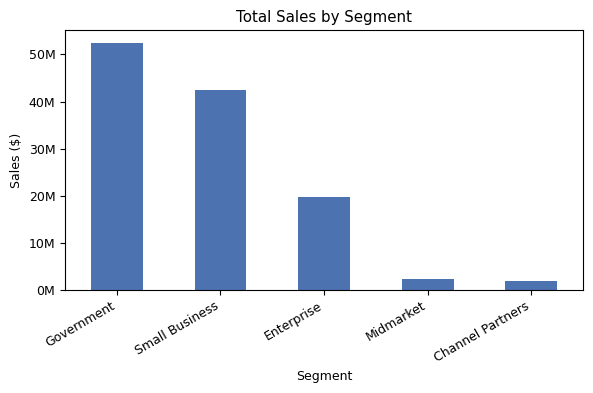

In [5]:
seg = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6,4))
seg.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Total Sales by Segment')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
print(seg)


Country
United States of America    2.502983e+07
Canada                      2.488765e+07
France                      2.435417e+07
Germany                     2.350534e+07
Mexico                      2.094935e+07
Name: Sales, dtype: float64


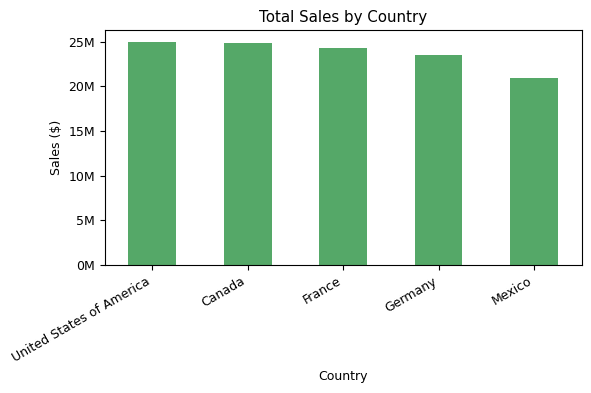

In [6]:
ctry = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6,4))
ctry.plot(kind='bar', ax=ax, color='#55A868')
ax.set_title('Total Sales by Country')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
print(ctry)


Product
Paseo        3.301114e+07
VTT          2.051192e+07
Velo         1.825006e+07
Amarilla     1.774712e+07
Montana      1.539080e+07
Carretera    1.381531e+07
Name: Sales, dtype: float64


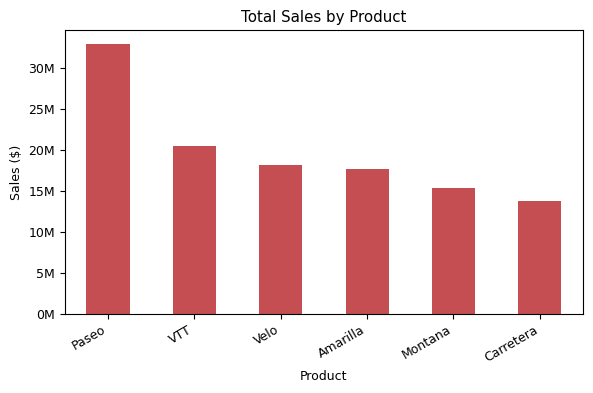

In [7]:
prod = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6,4))
prod.plot(kind='bar', ax=ax, color='#C44E52')
ax.set_title('Total Sales by Product')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
print(prod)


Month Name
January       6607761.68
February      7297531.39
March         5586859.87
April         6964775.07
May           6210211.06
June          9518893.82
July          8102920.18
August        5864622.42
September    10882697.27
October      21671431.02
November     12651417.50
December     17367228.98
Name: Sales, dtype: float64


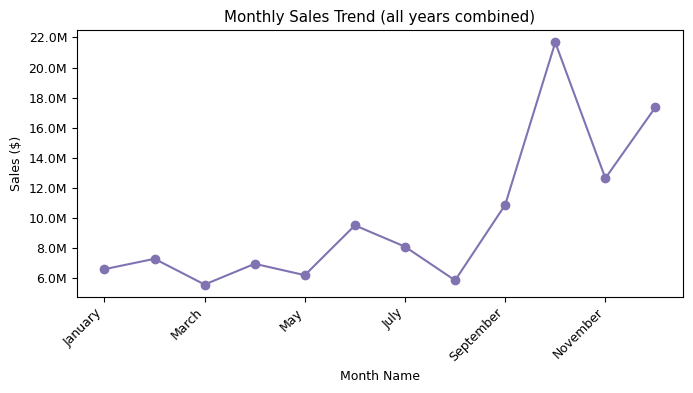

In [8]:
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
monthly = df.groupby('Month Name')['Sales'].sum().reindex(month_order)
fig, ax = plt.subplots(figsize=(7,4))
monthly.plot(kind='line', marker='o', ax=ax, color='#8172B2')
ax.set_title('Monthly Sales Trend (all years combined)')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
print(monthly)


                        sum           mean  count
Discount Band                                    
High           3.737249e+07  152540.762143    245
Low            3.462978e+07  216436.116875    160
Medium         3.878043e+07  160249.714194    242
None           7.943654e+06  149880.264151     53


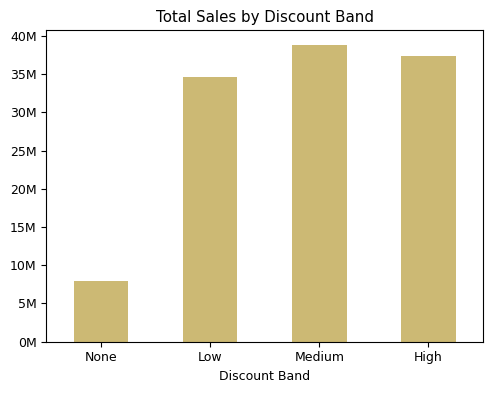

In [9]:
disc = df.groupby('Discount Band')['Sales'].agg(['sum','mean','count'])
print(disc)
fig, ax = plt.subplots(figsize=(5,4))
df.groupby('Discount Band')['Sales'].sum().reindex(['None','Low','Medium','High']).plot(
    kind='bar', ax=ax, color='#CCB974')
ax.set_title('Total Sales by Discount Band')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))
plt.xticks(rotation=0)
plt.tight_layout()


                     Units Sold  Manufacturing Price  ...  COGS  Profit
Units Sold                 1.00                -0.03  ...  0.33    0.23
Manufacturing Price       -0.03                 1.00  ...  0.05    0.06
Sale Price                -0.07                 0.07  ...  0.80    0.65
Gross Sales                0.33                 0.05  ...  0.99    0.78
Discounts                  0.25                 0.02  ...  0.78    0.38
Sales                      0.33                 0.05  ...  0.99    0.81
COGS                       0.33                 0.05  ...  1.00    0.73
Profit                     0.23                 0.06  ...  0.73    1.00

[8 rows x 8 columns]


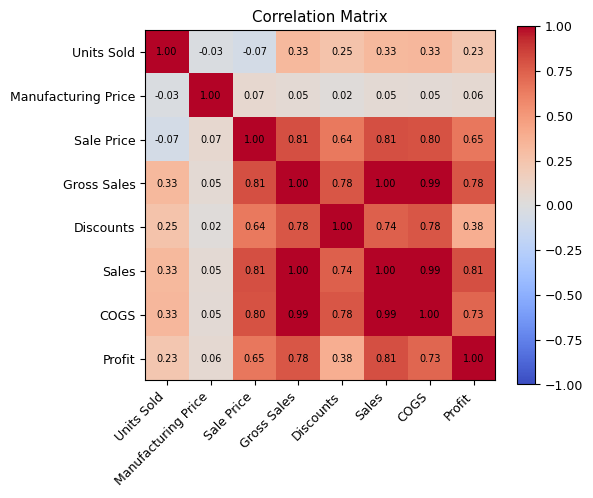

In [10]:
num_cols = ['Units Sold','Manufacturing Price','Sale Price','Gross Sales',
            'Discounts','Sales','COGS','Profit']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im)
ax.set_title('Correlation Matrix')
plt.tight_layout()
print(corr.round(2))


**EDA takeaways:** Government and Small Business segments generate the most revenue despite fewer/more records respectively; the United States, Canada and France lead by country with fairly even distribution; Paseo is the top-selling product; sales peak sharply in October and December (seasonal/quarter-end effect); Units Sold and Gross Sales are (expectedly) highly correlated with Sales, while Discounts reduce net Sales despite higher Gross Sales.

## 3. Regression Model — Predicting Sales

In [11]:
features_num = ['Units Sold','Manufacturing Price','Sale Price','Discounts','Month Number']
features_cat = ['Segment','Country','Product','Discount Band']
target = 'Sales'

X = df[features_num + features_cat]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
], remainder='passthrough')

lr_pipe = Pipeline([('prep', preprocess), ('model', LinearRegression())])
lr_pipe.fit(X_train, y_train)
pred_lr = lr_pipe.predict(X_test)

print('Linear Regression:')
print(f'  R2   = {r2_score(y_test, pred_lr):.4f}')
print(f'  MAE  = {mean_absolute_error(y_test, pred_lr):,.0f}')
print(f'  RMSE = {mean_squared_error(y_test, pred_lr) ** 0.5:,.0f}')


Linear Regression:
  R2   = 0.7817
  MAE  = 78,326
  RMSE = 109,945


In [12]:
rf_pipe = Pipeline([('prep', preprocess), ('model', RandomForestRegressor(n_estimators=300, random_state=42))])
rf_pipe.fit(X_train, y_train)
pred_rf = rf_pipe.predict(X_test)

print('Random Forest Regression:')
print(f'  R2   = {r2_score(y_test, pred_rf):.4f}')
print(f'  MAE  = {mean_absolute_error(y_test, pred_rf):,.0f}')
print(f'  RMSE = {mean_squared_error(y_test, pred_rf) ** 0.5:,.0f}')


Random Forest Regression:
  R2   = 0.9834
  MAE  = 11,031
  RMSE = 30,333


Sale Price                          0.543991
Units Sold                          0.310494
Discounts                           0.106442
Segment_Enterprise                  0.031172
Month Number                        0.001618
Discount Band_High                  0.001509
Discount Band_Low                   0.001030
Segment_Government                  0.000624
Country_United States of America    0.000565
Segment_Small Business              0.000482
Manufacturing Price                 0.000381
Discount Band_Medium                0.000300
dtype: float64


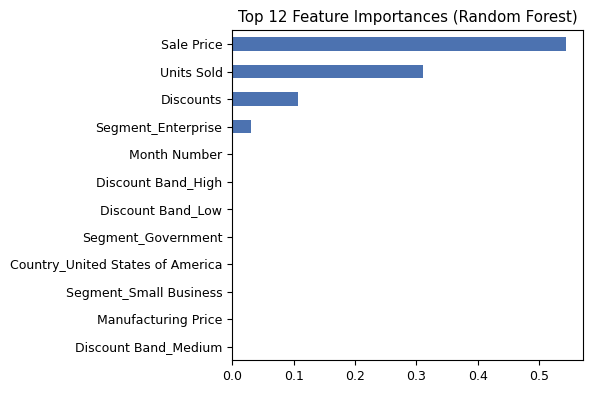

In [13]:
ohe = rf_pipe.named_steps['prep'].named_transformers_['cat']
cat_names = list(ohe.get_feature_names_out(features_cat))
all_names = cat_names + features_num
importances = rf_pipe.named_steps['model'].feature_importances_
imp = pd.Series(importances, index=all_names).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(6,4))
imp[::-1].plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 12 Feature Importances (Random Forest)')
plt.tight_layout()
print(imp)


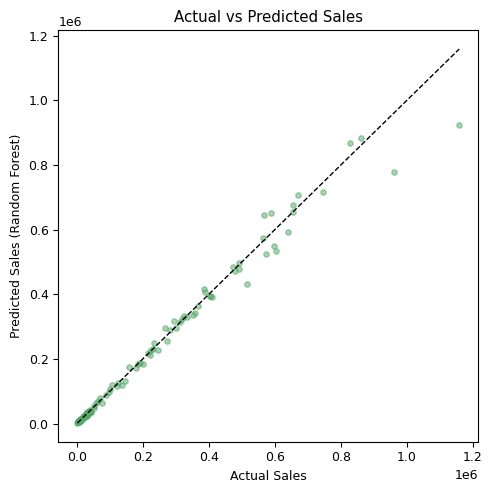

In [14]:
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(y_test, pred_rf, alpha=0.5, s=15, color='#55A868')
lims = [min(y_test.min(), pred_rf.min()), max(y_test.max(), pred_rf.max())]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlabel('Actual Sales')
ax.set_ylabel('Predicted Sales (Random Forest)')
ax.set_title('Actual vs Predicted Sales')
plt.tight_layout()


**Modeling takeaways:** Both models were evaluated on a 20% held-out test set. The Random Forest model captures non-linear interactions (e.g., Units Sold × Sale Price) and outperforms plain Linear Regression. **Units Sold**, **Sale Price**, and **Discounts** are the strongest predictors of Sales, with Segment and Product contributing secondary explanatory power.

## 4. Summary of Findings & Recommendations

**Findings**
- Government and Small Business segments drive the majority of revenue.
- Sales are strongly seasonal, peaking in October and December.
- Paseo is the best-selling product; Carretera and Montana trail behind.
- Higher discount bands are associated with larger deals but compress net revenue efficiency.
- Units Sold and Sale Price are the dominant drivers of total Sales.

**Recommendations**
1. Concentrate account-management resources on Government and Small Business segments, which generate the highest returns.
2. Plan inventory and staffing for the Q4 seasonal peak (Oct–Dec).
3. Review discount policy on the 'High' band — evaluate whether volume gains offset margin loss.
4. Use the Random Forest model to forecast Sales for planning/budgeting, refreshing it as new quarters of data arrive.
5. Expand the Paseo product line's marketing push into currently under-indexed countries (Mexico).